In [1]:
# Notebook Title: Housing Price Prediction: Sklearn Pipeline Refactoring (Assignment 1 - Part 2)
# Author: Saketh Vadlamudi
# Date: June 5, 2025
# Purpose: This notebook refactors the housing price prediction machine learning code
# to utilize scikit-learn's Pipeline and ColumnTransformer APIs, including a custom transformer
# for feature engineering, fulfilling Assignment 1 Part 2 requirements.

# --- Section 1: Setup and Imports ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tarfile
import urllib.request

# Scikit-learn imports
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# For setting random seeds for reproducibility
np.random.seed(42)

# Optional: Configure matplotlib for better plots
%matplotlib inline
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

print("Required libraries imported successfully.")


Required libraries imported successfully.


In [2]:

# --- Section 2: Get the Data ---

# ### 2.1 Data Acquisition
# This section fetches and loads the California Housing dataset.


def load_housing_data():
    return pd.read_csv("housing.csv")

# Execute the data fetching and loading

housing = load_housing_data()

print("\n--- Initial Housing Data Head ---")
print(housing.head())




--- Initial Housing Data Head ---
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [3]:

# --- Section 3: Create a Stratified Test Set ---

# ### 3.1 Stratified Sampling
# Creating income categories for stratified sampling to ensure representativeness.
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

print("\n--- Income Category Distribution ---")
print(housing["income_cat"].value_counts() / len(housing))

# Perform the stratified split
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

# Drop the income_cat column after splitting
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

print(f"\nTraining set shape: {strat_train_set.shape}")
print(f"Test set shape: {strat_test_set.shape}")
print("Stratified split performed and income category column removed.")



--- Income Category Distribution ---
income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

Training set shape: (16512, 10)
Test set shape: (4128, 10)
Stratified split performed and income category column removed.


In [4]:
# Separate features (X) and target (y)
housing_X = strat_train_set.drop("median_house_value", axis=1)
housing_y = strat_train_set["median_house_value"].copy()

# Define numerical and categorical features
numerical_features = list(housing_X.drop("ocean_proximity", axis=1).columns)
categorical_features = ['ocean_proximity']

print(f"\nNumerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")



Numerical features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features: ['ocean_proximity']


In [5]:

# --- Section 4: Custom Transformer for Feature Engineering ---

# ### 4.1 CombinedAttributesAdder Custom Transformer
# This custom transformer generates the new features: rooms_per_household,
# bedrooms_per_room, and population_per_household. It is designed to work
# seamlessly within a Scikit-learn pipeline, accepting and returning NumPy arrays.

# Calculate indices dynamically based on the order of numerical_features
# These indices are crucial because the ColumnTransformer will pass a NumPy array
# where columns are ordered as they appear in the `numerical_features` list.
tr_idx = numerical_features.index("total_rooms")
tb_idx = numerical_features.index("total_bedrooms")
pop_idx = numerical_features.index("population")
hh_idx = numerical_features.index("households")


In [6]:
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True,
                 total_rooms_idx=tr_idx, households_idx=hh_idx,
                 population_idx=pop_idx, total_bedrooms_idx=tb_idx):
        self.add_bedrooms_per_room = add_bedrooms_per_room
        self.total_rooms_idx = total_rooms_idx
        self.households_idx = households_idx
        self.population_idx = population_idx
        self.total_bedrooms_idx = total_bedrooms_idx

    def fit(self, X, y=None):
        return self # Nothing to learn here

    def transform(self, X):
        # X is expected to be a NumPy array when used inside a ColumnTransformer's sub-pipeline.
        # Ensure the indices are correctly mapped to the input X (which will be a slice of the original data).
        rooms_per_household = X[:, self.total_rooms_idx] / X[:, self.households_idx]
        population_per_household = X[:, self.population_idx] / X[:, self.households_idx]

        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, self.total_bedrooms_idx] / X[:, self.total_rooms_idx]
            # Use np.c_ to concatenate arrays column-wise
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

print("\nCustom Transformer 'CombinedAttributesAdder' defined.")


Custom Transformer 'CombinedAttributesAdder' defined.


In [7]:
# --- Section 5: Build the Full Scikit-learn Pipeline ---

# ### 5.1 Numerical Pipeline
# This pipeline handles missing values with imputation, generates new combined features,
# and then scales the numerical features.
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('attribs_adder', CombinedAttributesAdder(total_rooms_idx=tr_idx, households_idx=hh_idx,
                                              population_idx=pop_idx, total_bedrooms_idx=tb_idx)),
    ('std_scaler', StandardScaler()),
])
print("\nNumerical pipeline defined.")

# ### 5.2 Categorical Pipeline
# This pipeline handles categorical features using One-Hot Encoding.
# For simple cases, OneHotEncoder can be directly specified in ColumnTransformer.
# We'll define it here for clarity within the ColumnTransformer.
cat_pipeline = Pipeline([
    ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore')),
])
print("Categorical pipeline defined.")

# ### 5.3 ColumnTransformer for Preprocessing
# This combines the numerical and categorical pipelines, applying them to the
# appropriate columns.
full_preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, categorical_features), # Use cat_pipeline defined above
])
print("Full preprocessor (ColumnTransformer) defined.")



Numerical pipeline defined.
Categorical pipeline defined.
Full preprocessor (ColumnTransformer) defined.


In [8]:
# --- Section 6: Final End-to-End ML Pipeline and Training ---

# ### 6.1 Final ML Pipeline
# This top-level pipeline integrates the complete preprocessing steps with the
# chosen machine learning model (RandomForestRegressor in this case).
final_ml_pipeline = Pipeline([
    ('preprocessor', full_preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
])
print("\nFinal End-to-End ML Pipeline defined.")

# ### 6.2 Training the Pipeline
print("\nTraining the complete ML pipeline...")
final_ml_pipeline.fit(housing_X, housing_y)
print("Pipeline training complete.")



Final End-to-End ML Pipeline defined.

Training the complete ML pipeline...
Pipeline training complete.


In [10]:
# --- Section 7: Evaluation ---

# ### 7.1 Cross-Validation Evaluation
# Evaluate the pipeline's performance using cross-validation on the training data.
print("\nEvaluating the complete ML pipeline with Cross-Validation...")
cv_scores = cross_val_score(final_ml_pipeline, housing_X, housing_y,
                            scoring="neg_mean_squared_error", cv=10, n_jobs=-1)
rmse_cv_scores = np.sqrt(-cv_scores)

print(f"Pipeline CV RMSEs: {rmse_cv_scores}")
print(f"Pipeline Mean CV RMSE: {rmse_cv_scores.mean():.2f}")
print(f"Pipeline Std Dev CV RMSE: {rmse_cv_scores.std():.2f}")

# ### 7.2 Final Evaluation on the Test Set
# Apply the trained pipeline to the unseen test set for an unbiased performance estimate.
print("\nEvaluating the pipeline on the test set...")
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions_test = final_ml_pipeline.predict(X_test)
final_rmse_test = np.sqrt(mean_squared_error(y_test, final_predictions_test))
print(f"Final Test RMSE (Refactored Pipeline): {final_rmse_test:.2f}")


Evaluating the complete ML pipeline with Cross-Validation...
Pipeline CV RMSEs: [51537.67578146 48758.21137345 47244.6639255  51999.04540208
 47624.32461175 51876.65080786 52772.18239509 49810.68724233
 48685.69544598 54062.48437998]
Pipeline Mean CV RMSE: 50437.16
Pipeline Std Dev CV RMSE: 2206.83

Evaluating the pipeline on the test set...
Final Test RMSE (Refactored Pipeline): 48373.63



--- Feature Importances from Refactored Pipeline ---
median_income                 0.474153
ocean_proximity_INLAND        0.139403
population_per_household      0.122850
longitude                     0.058537
latitude                      0.056122
housing_median_age            0.044766
rooms_per_household           0.027696
bedrooms_per_room             0.022847
total_rooms                   0.012843
total_bedrooms                0.012412
households                    0.012263
population                    0.011751
ocean_proximity_NEAR OCEAN    0.002250
ocean_proximity_<1H OCEAN     0.001204
ocean_proximity_NEAR BAY      0.000817
ocean_proximity_ISLAND        0.000086
dtype: float64


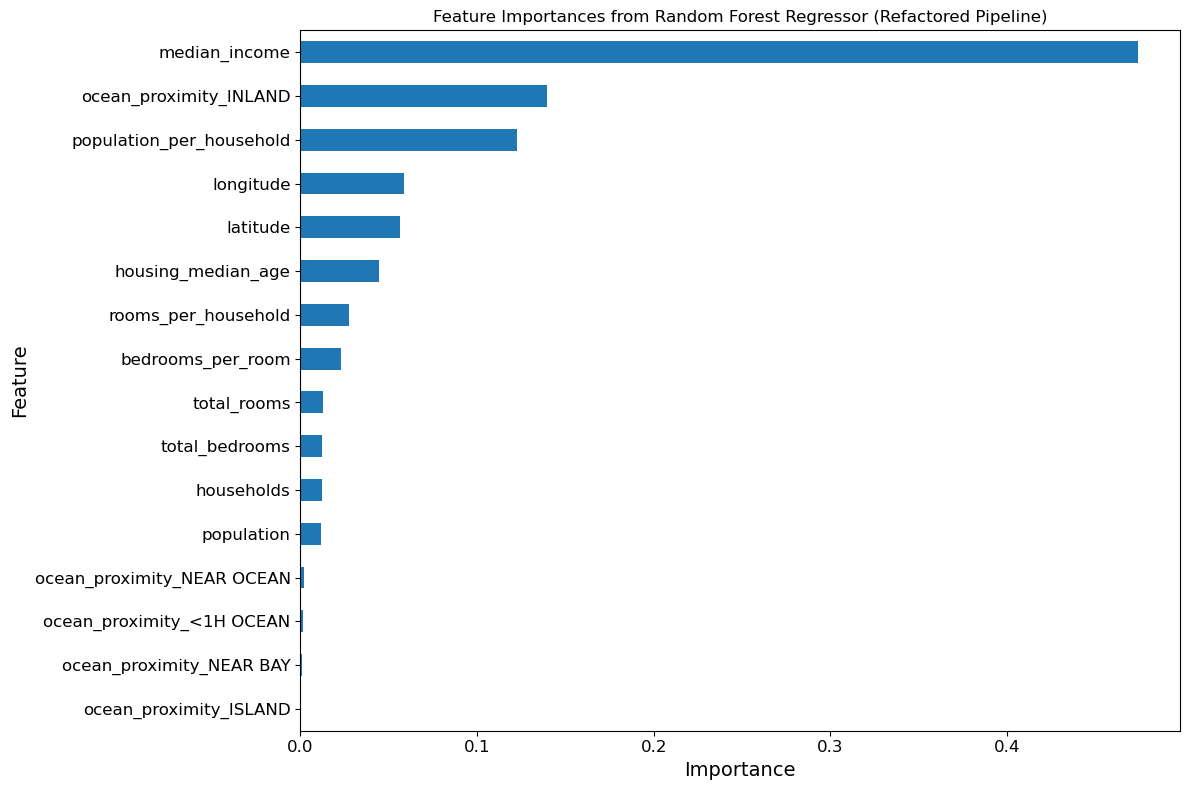


Refactoring complete. The ML workflow is now robust and streamlined using Scikit-learn pipelines.


In [11]:


# --- Section 8: Inspection and Discussion (Optional) ---

# ### 8.1 Inspecting Feature Importances (from the trained regressor in the pipeline)
# After fitting the pipeline, you can access the final estimator to inspect feature importances.
# Note: Getting feature names after ColumnTransformer and custom transformers can be complex.
# This is a simplified approach assuming a direct mapping for numerical features.
try:
    feature_importances = final_ml_pipeline.named_steps['regressor'].feature_importances_

    # Get processed feature names
    # Numerical features + added features + one-hot encoded categorical features
    # Order of numerical features + new features depends on how CombinedAttributesAdder adds them (at the end)
    # The ColumnTransformer combines them: numerical_features (processed) + categorical_features (one-hot encoded)

    # Manually construct feature names after pipeline processing for display
    # Original numerical features + 3 new features
    processed_numerical_feature_names = numerical_features + ["rooms_per_household", "population_per_household", "bedrooms_per_room"]

    # Get names of one-hot encoded categorical features
    # Access the OneHotEncoder from the fitted preprocessor
    one_hot_encoder = final_ml_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['one_hot_encoder']
    cat_feature_names_out = list(one_hot_encoder.get_feature_names_out(categorical_features))

    # Combine all feature names in the order they appear in the final transformed data
    all_processed_feature_names = processed_numerical_feature_names + cat_feature_names_out

    # Create a Series for easier sorting and display
    importances_series = pd.Series(feature_importances, index=all_processed_feature_names)
    sorted_importances = importances_series.sort_values(ascending=False)

    print("\n--- Feature Importances from Refactored Pipeline ---")
    print(sorted_importances)

    plt.figure(figsize=(12, 8))
    sorted_importances.plot(kind='barh')
    plt.title('Feature Importances from Random Forest Regressor (Refactored Pipeline)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.gca().invert_yaxis() # Highest importance at the top
    plt.tight_layout()
    plt.show()

except AttributeError:
    print("\nFeature importances are not available for the selected regressor or it has not been fitted.")
except KeyError:
    print("\nCould not retrieve feature names from the ColumnTransformer steps. Check names.")

print("\nRefactoring complete. The ML workflow is now robust and streamlined using Scikit-learn pipelines.")